In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from saidownscale import downscaling_utils, run_bcsd

# 0. Get data

In [2]:
RUN_PARAMETERS = {
    "gcm": "CESM2-WACCM",
    "train_period_start": 1978,
    "train_period_end": 2014,
    "predict_period_start": 2015,
    "predict_period_end": 2100,
    "var_name": "tas",
}

In [3]:
dict_all_detrended = run_bcsd.get_all_data(
    gcm=RUN_PARAMETERS["gcm"], var_name=RUN_PARAMETERS["var_name"], verbose=True
)

dict_all_not_detrended = run_bcsd.get_all_data(
    gcm=RUN_PARAMETERS["gcm"], var_name=RUN_PARAMETERS["var_name"], verbose=True
)

Loaded data: 1.15 seconds
Subset time: 0.00 seconds
Loaded data: 0.98 seconds
Subset time: 0.00 seconds


### Subset data to demo region

In [4]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'Finland'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
country_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = country_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

In [6]:
for key in dict_all_detrended:
    if key in ["obs", "era5"]:
        dict_all_detrended[key] = downscaling_utils.subset_space(
            dict_all_detrended[key],
            coord_bounds_list=[lat_min - 1, lat_max + 1, lon_min - 1, lon_max + 1],
        )
    else:
        dict_all_detrended[key] = downscaling_utils.subset_space(
            dict_all_detrended[key], coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
        )

for key in dict_all_not_detrended:
    if key in ["obs", "era5"]:
        dict_all_not_detrended[key] = downscaling_utils.subset_space(
            dict_all_not_detrended[key],
            coord_bounds_list=[lat_min - 1, lat_max + 1, lon_min - 1, lon_max + 1],
        )
    else:
        dict_all_not_detrended[key] = downscaling_utils.subset_space(
            dict_all_not_detrended[key], coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
        )

# 1. Preprocess data

In [7]:
RECHUNK_WORKFLOW = True  # flag: whether to rechunk data depending on the step
VERBOSE = True

In [8]:
dict_all_detrended = run_bcsd.preprocess_data(
    dict_all_detrended,
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=True,
)

Rechunked obs to full space: 4.20 seconds
Interpolated obs to coarse grid: 55.03 seconds
Detrended data: 8.20 seconds


In [ ]:
dict_all_not_detrended = run_bcsd.preprocess_data(
    dict_all_not_detrended,
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=False,
)

Rechunked obs to full space: 4.15 seconds


# 2. Bias correct with quantile mapping

In [ ]:
dict_all_detrended = run_bcsd.bias_correct(
    dict_all=dict_all_detrended,
    var_name=RUN_PARAMETERS["var_name"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=True,
    do_windowing=False,
)

In [ ]:
dict_all_not_detrended = run_bcsd.bias_correct(
    dict_all=dict_all_not_detrended,
    var_name=RUN_PARAMETERS["var_name"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=False,
    do_windowing=False,
)

# Examine influence of detrending at a single point (before doing the downscaling step)

In [ ]:
xind = 8
yind = 8

In [ ]:
scenario = "scenario"

plt.figure(figsize=(19, 7))
for m in np.arange(1, 13):
    plt.subplot(3, 4, m)
    (
        dict_all_detrended[scenario + "_trend"][:, xind, yind].where(
            dict_all_detrended[scenario + "_trend"]["time.month"] == m
        )
    ).plot()
    plt.title(m)
    plt.ylabel("Temperature (K)")
    plt.axvspan(
        "1978-01-01T00:00:00.000000000",
        "2014-01-01T00:00:00.000000000",
        color="gray",
        alpha=0.3,
    )
    plt.axhline(y=0, linestyle=":", color="black", alpha=0.5)
plt.tight_layout()

In [ ]:
plt.figure(figsize=(19, 7))
for m in np.arange(1, 13):
    plt.subplot(3, 4, m)
    plt.hist(
        dict_all_detrended[scenario + "_detrended"][:, xind, yind]
        .where(dict_all_detrended[scenario + "_detrended"]["time.month"] == m)
        .where(
            dict_all_detrended[scenario + "_detrended"]["time"]
            > dict_all_detrended["model_" + scenario]["time"][0]
        ),
        alpha=0.4,
        label="Detrended",
    )
    plt.hist(
        dict_all_detrended["model_" + scenario][:, xind, yind].where(
            dict_all_detrended["model_" + scenario]["time.month"] == m
        ),
        alpha=0.4,
        label="Original",
    )
    plt.title(m)
    plt.ylabel("Temperature (K)")
plt.tight_layout()
plt.legend()

In [ ]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
(
    dict_all_detrended[scenario + "_detrended"][:, xind, yind]
    .rolling(time=365 * 5)
    .mean()
    .plot(label="Detrended")
)
(
    dict_all_detrended["model_" + scenario][:, xind, yind]
    .rolling(time=365 * 5)
    .mean()
    .plot(label="Raw GCM data")
)
plt.legend()
plt.subplot(1, 2, 2)
(
    dict_all_detrended[scenario + "_trend"][:, xind, yind]
    .rolling(time=365 * 5)
    .mean()
    .plot(label="Trend")
)
plt.legend()
plt.axhline(y=0, linestyle=":", color="k")
plt.tight_layout()

### Plots looking at differences between bias correction choices

In [ ]:
output_detrended = dict_all_detrended[scenario + "_debiased"]
output_not_detrended = dict_all_not_detrended[scenario + "_debiased"]

In [ ]:
plt.figure(figsize=(15, 5))
plt.hist(
    output_detrended.where(output_detrended["time.month"] == 6)[:, xind, yind],
    bins=np.arange(260, 315, 0.25),
    alpha=0.3,
    label="v1: our detrending",
)
plt.hist(
    output_not_detrended.where(output_not_detrended["time.month"] == 6)[:, xind, yind],
    alpha=0.3,
    bins=np.arange(260, 315, 0.25),
    label="v2: no detrending",
)
plt.legend()

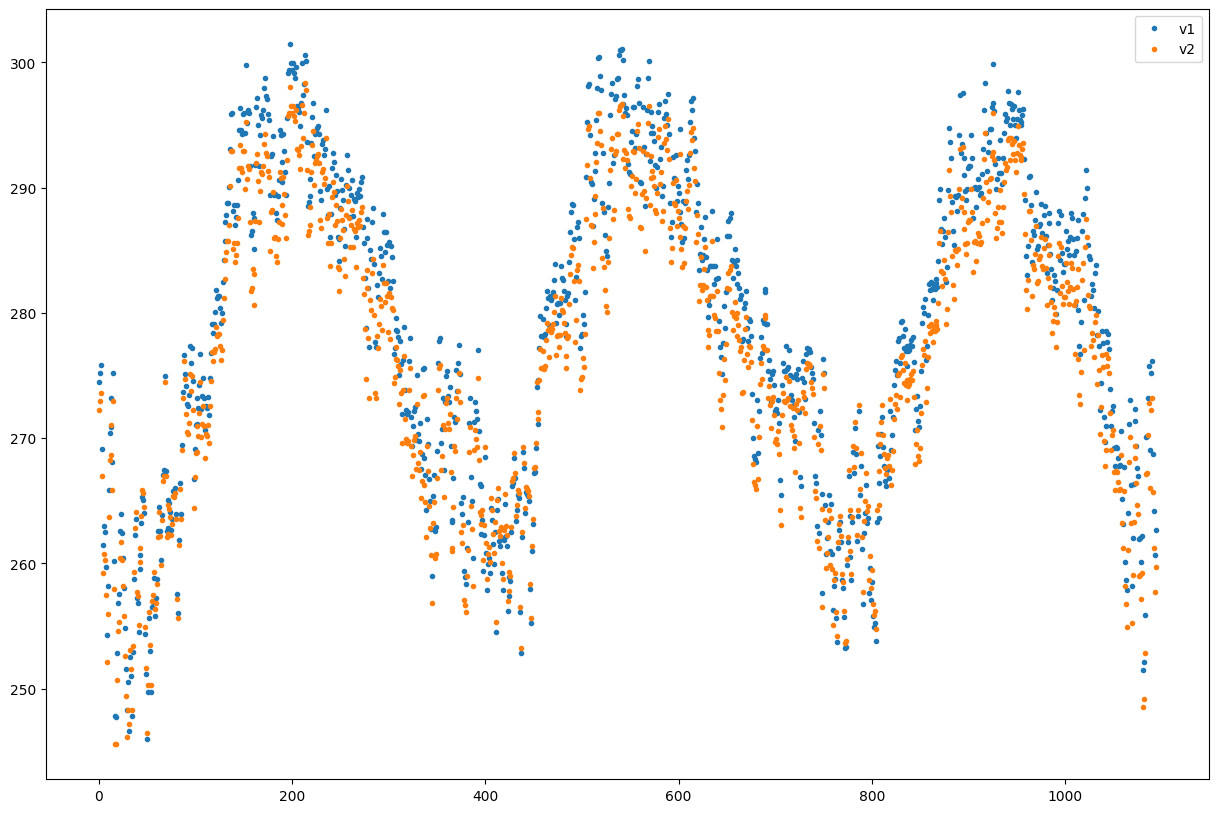

In [32]:
plt.figure(figsize=(15, 10))
plt.plot(output_detrended[-365 * 3 :, xind, yind], ".", label="v1")
plt.plot(output_not_detrended[-365 * 3 :, xind, yind], ".", label="v2")
plt.legend()

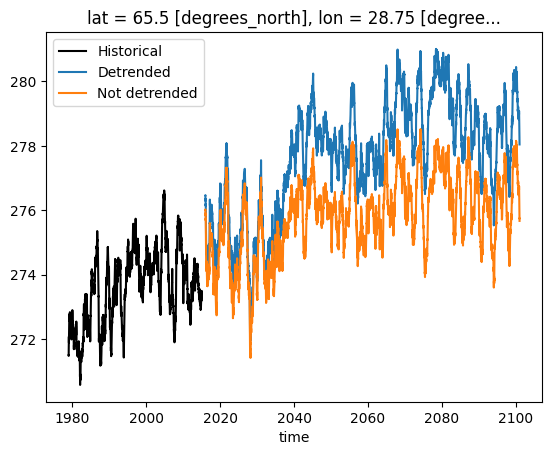

In [33]:
(dict_all_detrended["model_hist"][:, xind, yind].rolling(time=365).mean()).plot(
    label="Historical", color="k"
)
(output_detrended[:, xind, yind].rolling(time=365).mean()).plot(label="Detrended")
(output_not_detrended[:, xind, yind].rolling(time=365).mean()).plot(label="Not detrended")
plt.legend()

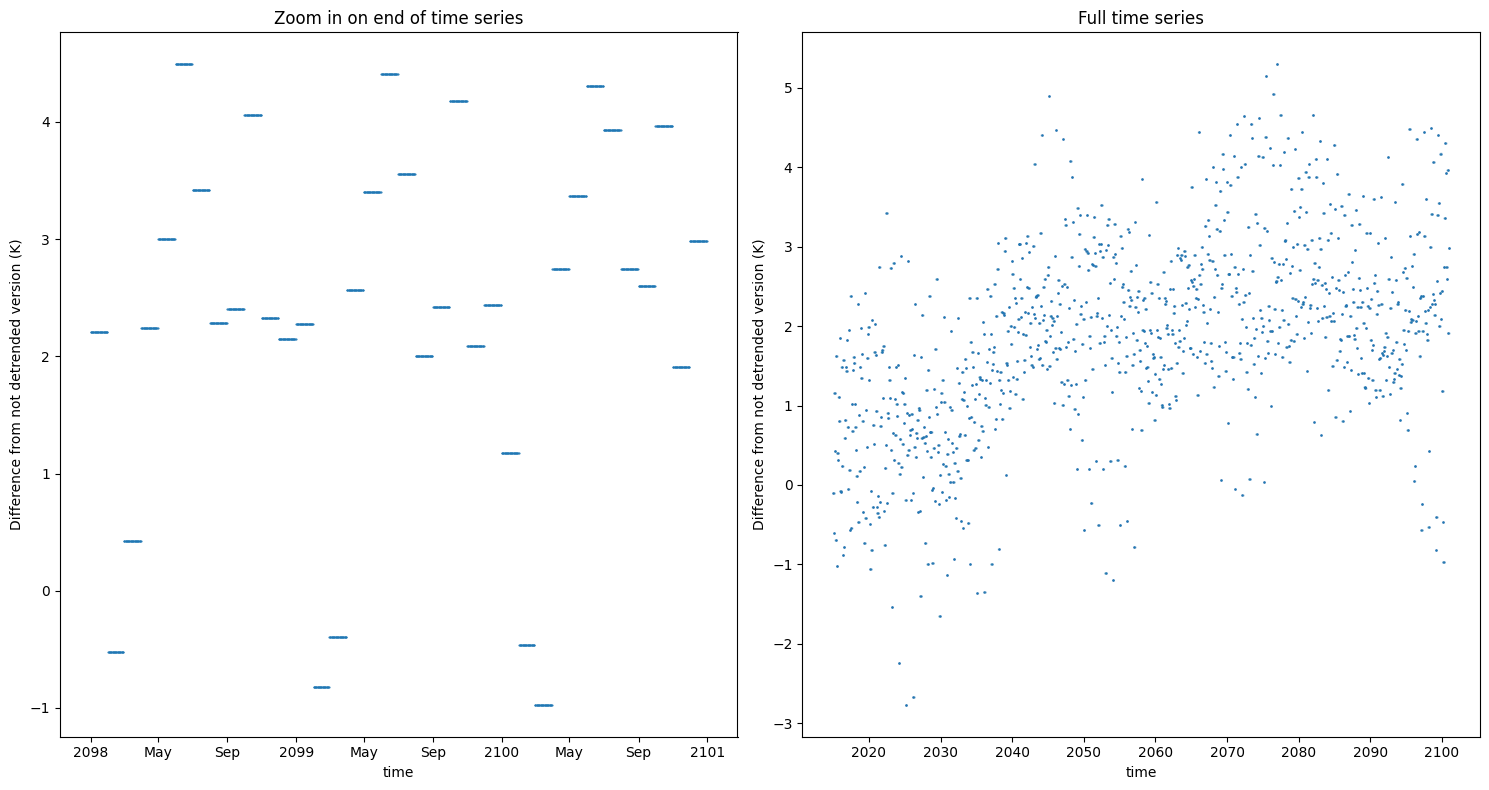

In [35]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
(output_detrended[-365 * 3 :, xind, yind] - output_not_detrended[-365 * 3 :, xind, yind]).plot(
    marker=".", linewidth=0, alpha=1, markersize=1
)
plt.ylabel("Difference from not detrended version (K)")
plt.title("Zoom in on end of time series")

plt.subplot(1, 2, 2)
(output_detrended[:, xind, yind] - output_not_detrended[:, xind, yind]).plot(
    marker=".", linewidth=0, alpha=0.1, markersize=1
)
plt.ylabel("Difference from not detrended version (K)")
plt.title("Full time series")
plt.tight_layout()

In [36]:
print("Max effect of detrending on any single day")
print(np.nanmax(output_detrended - output_not_detrended))
print(np.nanmin(output_detrended - output_not_detrended))

Max effect of detrending on any single day
6.034485
-2.8460388


### Demo CDF figures for high end of distribution

In [21]:
value = np.percentile(dict_all_detrended["model_scenario"].values[:, xind, yind], 99.99)
idx = np.argmin(np.abs(dict_all_detrended["model_scenario"].values[:, xind, yind] - value))
print(idx)

print("Original value")
print(dict_all_detrended["model_scenario"].values[idx, xind, yind])
print("Original max value at that location")
print(np.nanmax(dict_all_detrended["model_scenario"].values[:, xind, yind]))
print("Original detrended value")
print(dict_all_detrended["scenario_detrended"].values[idx, xind, yind])
print("Debiased value with detrending")
print(output_detrended.values[idx, xind, yind])
print("Debiased value without detrending")
print(output_not_detrended.values[idx, xind, yind])

14448
Original value
299.11395
Original max value at that location
300.3471
Original detrended value
280.5179
Debiased value with detrending
301.69238
Debiased value without detrending
299.7043


(0.9, 1.01)

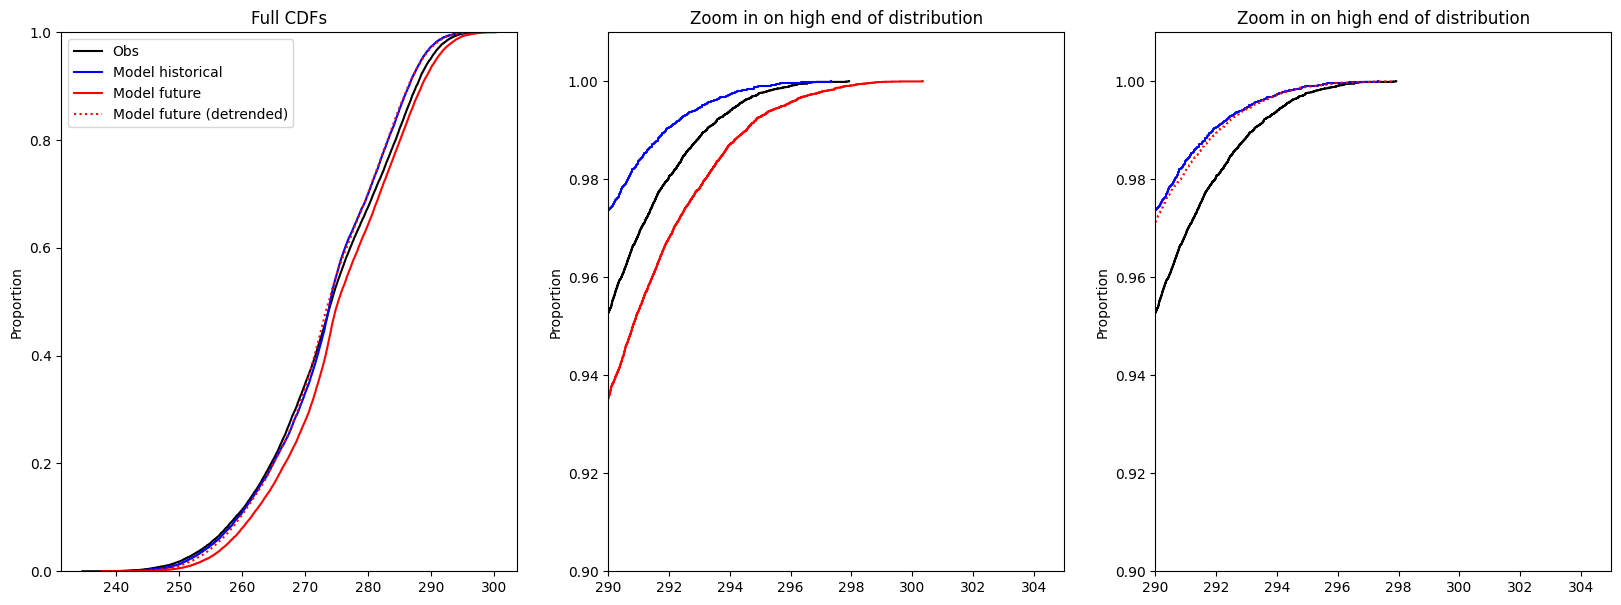

In [23]:
plt.figure(figsize=(20, 7))
plt.subplot(1, 3, 1)
plt.title("Full CDFs")
sns.ecdfplot(
    data=dict_all_detrended["obs_coarse"].as_numpy().values[:, xind, yind], label="Obs", color="k"
)
sns.ecdfplot(
    data=dict_all_detrended["model_hist"].values[:, xind, yind], label="Model historical", color="b"
)
sns.ecdfplot(
    data=dict_all_detrended["model_scenario"].values[:, xind, yind], label="Model future", color="r"
)
sns.ecdfplot(
    data=dict_all_detrended["scenario_detrended"].values[:, xind, yind],
    label="Model future (detrended)",
    color="r",
    linestyle=":",
)
plt.legend()
plt.subplot(1, 3, 2)
plt.title("Zoom in on high end of distribution")
sns.ecdfplot(
    data=dict_all_detrended["obs_coarse"].as_numpy().values[:, xind, yind], label="Obs", color="k"
)
sns.ecdfplot(
    data=dict_all_detrended["model_hist"].values[:, xind, yind], label="Model historical", color="b"
)
sns.ecdfplot(
    data=dict_all_detrended["model_scenario"].values[:, xind, yind], label="Model future", color="r"
)
plt.xlim([290, 305])
plt.ylim([0.9, 1.01])

plt.subplot(1, 3, 3)
plt.title("Zoom in on high end of distribution")
sns.ecdfplot(
    data=dict_all_detrended["obs_coarse"].as_numpy().values[:, xind, yind], label="Obs", color="k"
)
sns.ecdfplot(
    data=dict_all_detrended["model_hist"].values[:, xind, yind], label="Model historical", color="b"
)
sns.ecdfplot(
    data=dict_all_detrended["scenario_detrended"].values[:, xind, yind],
    label="Model future",
    color="r",
    linestyle=":",
)
plt.xlim([290, 305])
plt.ylim([0.9, 1.01])